### Notebook Purpose: Exploratory Data Analysis
- Profile schema, splits, and ID coverage for the 15-minute OHLCV dataset
- Quantify zero inflation and validate leakage-safe 15-minute grids
- Visualize intraday/day-of-week patterns, volume distributions, and stationarity
- Save diagnostic EDA plots under `results/plots/eda/` for reuse

### Note
- Shared inputs/outputs and execution conventions are documented in the project README.


In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Minimal environment setup to keep the notebook focused on the core experiments.
# If you run this elsewhere, update PROJECT_DIR accordingly.
PROJECT_DIR = Path("/content/drive/MyDrive/0.Portfolio/electricity_price_forecasting").resolve()


In [ ]:
project_str = str(PROJECT_DIR)
if project_str not in sys.path:
    sys.path.insert(0, project_str)

DATA_DIR         = PROJECT_DIR / "data"
RESULTS_DIR      = PROJECT_DIR / "results"
METRICS_DIR      = RESULTS_DIR / "metrics"
MODELS_DIR       = RESULTS_DIR / "models"
WINDOW_INDEX_DIR = RESULTS_DIR / "window_index"
LOGS_DIR         = RESULTS_DIR / "logs"
CACHE_DIR        = RESULTS_DIR / "cache"
PLOTS_DIR        = RESULTS_DIR / "plots"

for p in [
    RESULTS_DIR,
    PLOTS_DIR,
    METRICS_DIR,
    MODELS_DIR,
    WINDOW_INDEX_DIR,
    LOGS_DIR,
    CACHE_DIR,
    PLOTS_DIR / "models",
    PLOTS_DIR / "eval/curves",
    PLOTS_DIR / "eval/tables",
    PLOTS_DIR / "eda",
    PLOTS_DIR / "feature_engineering",
]:
    p.mkdir(parents=True, exist_ok=True)


# 01 — Exploratory Data Analysis (EDA)

This notebook establishes the **data characteristics** that motivate the modeling choices in notebooks **03–05**:

- **Shape**: multi-ID OHLCV series sampled on an irregular transaction stream
- **Sparsity / zero inflation**: *volume is mostly zero on a dense 15‑minute grid*
- **Periodicity**: intraday / day-of-week patterns (Berlin local time)
- **Active ratio**: fraction of steps where volume > 0 (used for *active sMAPE*)

**Key design decision used throughout the project**  
We convert each ID into a **continuous 15‑minute grid** (snap + deduplicate + fill) so that:
- windows can be indexed reproducibly by **(ID_code, start_pos)**,
- and NaNs are eliminated by construction (prices ffill/bfill, volume → 0).

## 1) Dataset schema & time bounds

We work with:
- Train period: **2021–2023** (parquet)
- Test period: **2024** (parquet)
- Target columns (canonical): **high / low / close / volume**
- Canonical evaluation uses **volume > 0** as the *active* mask.

In [ ]:
# === Inspect Parquet schema ===

try:
    import pyarrow.dataset as ds
    dset = ds.dataset(str(TEST_PARQUET), format="parquet")
    print("TEST schema:")
    print(dset.schema)
except Exception as e:
    print("WARN: Could not inspect schema via pyarrow.dataset:", repr(e))

TEST schema:
ExecutionTime: timestamp[ns, tz=UTC]
ID: dictionary<values=string, indices=int32, ordered=0>
high: float
low: float
close: float
volume: float
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 809


## 2) Stable ID mapping: raw string ID ↔ integer code

The modeling notebooks store `window_index` as `(ID_code, start_pos)` for reproducibility.

- `raw_id` lives in parquet (string)
- `ID_code` is a stable integer (sorted raw IDs → 0..N-1)

We cache the mapping once to avoid rescanning the parquet every run.

In [ ]:
# === Build or load ID mapping ===

from electricity_forecasting.io.id_mapping import (
    load_id_mapping_json,
    scan_unique_ids_from_parquet,
    build_id_mapping,
    save_id_mapping_json,
)

ID_MAP_PATH = RESULTS_DIR / "window_index" / "id_code_mapping.json"

if ID_MAP_PATH.exists():
    ID_TO_CODE, CODE_TO_ID, ALL_CODES = load_id_mapping_json(ID_MAP_PATH)
    print("OK: Loaded cached ID mapping | n_ids:", len(ALL_CODES))
else:
    ids_raw = scan_unique_ids_from_parquet(str(TEST_PARQUET), id_col="ID")
    ID_TO_CODE, CODE_TO_ID, ALL_CODES = build_id_mapping(ids_raw)
    save_id_mapping_json(ID_MAP_PATH, id_to_code=ID_TO_CODE, code_to_id=CODE_TO_ID)
    print("OK: Built + saved ID mapping | n_ids:", len(ALL_CODES))


OK: Loaded cached ID mapping | n_ids: 672


## 3) From sparse observations to a continuous 15‑minute grid (single ID)

The raw parquet rows can be sparse and may contain duplicate timestamps.
The canonical grid builder enforces:

- Snap timestamps to 15‑minute buckets (floor)
- Deduplicate timestamps (keep last)
- Reindex to a full 15‑minute range (continuous block)
- Fill:
  - `volume`: missing → 0
  - `high/low/close`: forward/back fill (and final fill 0 as a guard)

This eliminates NaNs and makes windowing deterministic.

In [ ]:
# === Sample IDs for EDA deep dive ===

import random

SAMPLE_N_IDS = 3
sample_codes = random.sample(ALL_CODES, k=min(SAMPLE_N_IDS, len(ALL_CODES)))
sample_raw_ids = [CODE_TO_ID[c] for c in sample_codes]
print("Sample ID codes:", sample_codes)
print("Sample raw IDs  :", sample_raw_ids)

Sample ID codes: [543, 569, 140]
Sample raw IDs  : ['Tue15Q4', 'Tue22Q2', 'Mon11Q1']


In [ ]:
# === Single-ID EDA utilities ===

import pandas as pd
from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema
from electricity_forecasting.preprocessing.features import build_15min_grid

ID_COL = "ID"
TIME_COL = "ExecutionTime"
TARGET_COLS = ["high", "low", "close", "volume"]

# Load sparse observed rows for one ID (test year) and build a dense grid
raw_id = str(sample_raw_ids[0])

df_obs = load_parquet_filtered(
    parquet_path=str(TEST_PARQUET),
    ids=[raw_id],
    columns=[TIME_COL, ID_COL, "high", "low", "close", "volume"],
    time_min=TEST_START,
    time_max=TEST_END,
)
df_obs = enforce_schema(df_obs)

print("Observed rows:", len(df_obs))
print(df_obs.head(3))

df_grid = build_15min_grid(
    df_obs=df_obs,
    ids=None,
    start_utc=TEST_START,
    end_utc=TEST_END,
    freq=FREQ,
    id_col=ID_COL,
    time_col=TIME_COL,
    price_cols=PRICE_COLS,
    volume_col=VOLUME_COL,
)

print("Grid rows:", len(df_grid))
print(df_grid.head(3))
print("Any NaNs?", df_grid[TARGET_COLS].isna().any().to_dict())

dt = pd.to_datetime(df_grid[TIME_COL], utc=True).diff().dropna().value_counts().head(3)
print("Most common time deltas:", dt.to_dict())

Observed rows: 21798
              ExecutionTime       ID  high  low  close  volume
0 2024-01-06 19:30:00+00:00  Tue15Q4   0.0  0.0    0.0     0.0
1 2024-01-06 19:45:00+00:00  Tue15Q4   0.0  0.0    0.0     0.0
2 2024-01-06 20:00:00+00:00  Tue15Q4   0.0  0.0    0.0     0.0
Grid rows: 35136
        ID             ExecutionTime  high  low  close  volume  pos
0  Tue15Q4 2024-01-01 00:00:00+00:00   0.0  0.0    0.0     0.0    0
1  Tue15Q4 2024-01-01 00:15:00+00:00   0.0  0.0    0.0     0.0    1
2  Tue15Q4 2024-01-01 00:30:00+00:00   0.0  0.0    0.0     0.0    2
Any NaNs? {'high': False, 'low': False, 'close': False, 'volume': False}
Most common time deltas: {Timedelta('0 days 00:15:00'): 35135}


In [ ]:
# === Grid sanity check ===

df_one = df_grid[df_grid[ID_COL].astype(str) == raw_id].copy()
dt = pd.to_datetime(df_one[TIME_COL], utc=True).diff().dropna().value_counts().head(3)
print("Most common time deltas:", dt.to_dict())

Most common time deltas: {Timedelta('0 days 00:15:00'): 35135}


## 4) Sparsity / zero inflation

On the dense grid, **volume is zero for most timestamps**.
This motivates *hurdle modeling* (active classification + conditional regression).

We measure:

- **Active ratio** = mean(volume > 0)  
  (same mask used for active sMAPE in evaluation)
- Distribution of active ratio across a sample of IDs.

Computed active ratios for 30 IDs in 1.8s
Active ratio summary:
  mean  : 0.04588741064071655
  median: 0.04632001370191574
  min   : 0.02635473571717739
  max   : 0.07038365304470062
Saved: active_ratio_hist.png


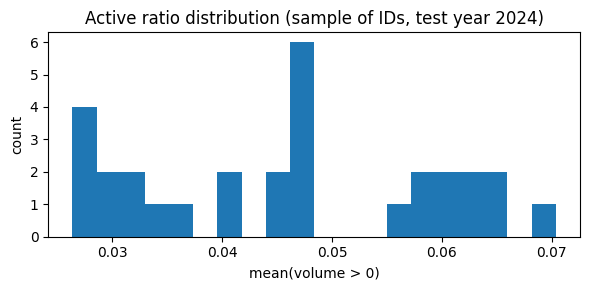

In [ ]:
# === Active ratio distribution ===

import time
import numpy as np
import random
import matplotlib.pyplot as plt

from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema
from electricity_forecasting.preprocessing.features import build_15min_grid


GLOBAL_SAMPLE_N_IDS = 30
codes = random.sample(ALL_CODES, k=min(GLOBAL_SAMPLE_N_IDS, len(ALL_CODES)))
ids_raw = [str(CODE_TO_ID[c]) for c in codes]

t0 = time.time()

df_obs = load_parquet_filtered(
    parquet_path=str(TEST_PARQUET),
    ids=ids_raw,
    columns=[TIME_COL, ID_COL, "high", "low", "close", VOLUME_COL],
    time_min=TEST_START,
    time_max=TEST_END,
)
df_obs = enforce_schema(df_obs)

df_grid = build_15min_grid(
    df_obs=df_obs,
    ids=None,
    start_utc=TEST_START,
    end_utc=TEST_END,
    freq=FREQ,
    id_col=ID_COL,
    time_col=TIME_COL,
    price_cols=PRICE_COLS,
    volume_col=VOLUME_COL,
)

# Active ratio per ID on dense grid
ratios = (
    (df_grid[VOLUME_COL] > 0)
    .groupby(df_grid[ID_COL].astype(str))
    .mean()
    .astype(np.float32)
    .to_numpy()
)

print(f"Computed active ratios for {len(ratios)} IDs in {(time.time()-t0):.1f}s")

print("Active ratio summary:")
print("  mean  :", float(ratios.mean()))
print("  median:", float(np.median(ratios)))
print("  min   :", float(ratios.min()))
print("  max   :", float(ratios.max()))

plt.figure(figsize=(6, 3))
plt.hist(ratios, bins=20)
plt.title("Active ratio distribution (sample of IDs, test year 2024)")
plt.xlabel("mean(volume > 0)")
plt.ylabel("count")
plt.tight_layout()

out_png = PLOTS_DIR / "eda" / "active_ratio_hist.png"
plt.savefig(out_png, dpi=160)
print("Saved:", out_png.name)

Volume zero ratio (sample IDs, dense grid): 0.953796
Non-zero volume count: 48703
Non-zero volume quantiles: {'p50': np.float64(2.2750000953674316), 'p90': np.float64(36.54499969482429), 'p99': np.float64(127.04850296020531), 'p999': np.float64(206.6650503234894)}
Saved: volume_log1p_justification.png


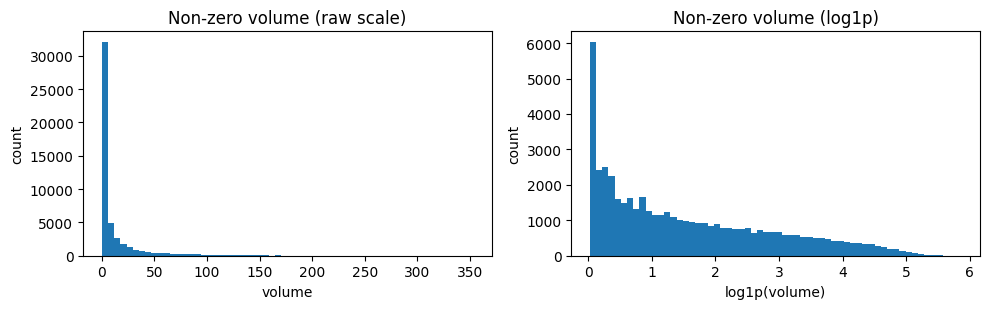

In [ ]:
# === Volume distribution and log1p ===

import numpy as np
import matplotlib.pyplot as plt

from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema
from electricity_forecasting.preprocessing.features import build_15min_grid


# Sample a bounded set of IDs for stable runtime
VOL_N_IDS = 30
codes = random.sample(ALL_CODES, k=min(VOL_N_IDS, len(ALL_CODES)))
ids_raw = [str(CODE_TO_ID[c]) for c in codes]

df_obs = load_parquet_filtered(
    parquet_path=str(TEST_PARQUET),
    ids=ids_raw,
    columns=[TIME_COL, ID_COL, "high", "low", "close", VOLUME_COL],
    time_min=TEST_START,
    time_max=TEST_END,
)
df_obs = enforce_schema(df_obs)

df_grid = build_15min_grid(
    df_obs=df_obs,
    ids=None,
    start_utc=TEST_START,
    end_utc=TEST_END,
    freq=FREQ,
)

v = df_grid[VOLUME_COL].to_numpy(np.float32)
zero_ratio = float((v <= 0).mean())
pos = v[v > 0]

print("Volume zero ratio (sample IDs, dense grid):", round(zero_ratio, 6))
print("Non-zero volume count:", int(pos.size))

if pos.size > 0:
    q = np.quantile(pos, [0.5, 0.9, 0.99, 0.999]).astype(float)
    print("Non-zero volume quantiles:", {"p50": q[0], "p90": q[1], "p99": q[2], "p999": q[3]})

    plt.figure(figsize=(10, 3.2))
    plt.subplot(1, 2, 1)
    plt.hist(pos, bins=60)
    plt.title("Non-zero volume (raw scale)")
    plt.xlabel("volume")
    plt.ylabel("count")

    plt.subplot(1, 2, 2)
    plt.hist(np.log1p(pos), bins=60)
    plt.title("Non-zero volume (log1p)")
    plt.xlabel("log1p(volume)")
    plt.ylabel("count")

    plt.tight_layout()
    out_png = PLOTS_DIR / "eda" / "volume_log1p_justification.png"
    plt.savefig(out_png, dpi=160)
    print("Saved:", out_png.name)
else:
    print("WARN: No non-zero volume in this sample.")

## 5) Periodicity (Berlin local time)

Electricity markets typically exhibit strong intraday patterns.
We visualize **active rate** by:

- hour-of-day (0..23)
- day-of-week (Mon..Sun)

This is exactly why we include Berlin-time features in feature engineering.

Saved: active_rate_heatmap.png


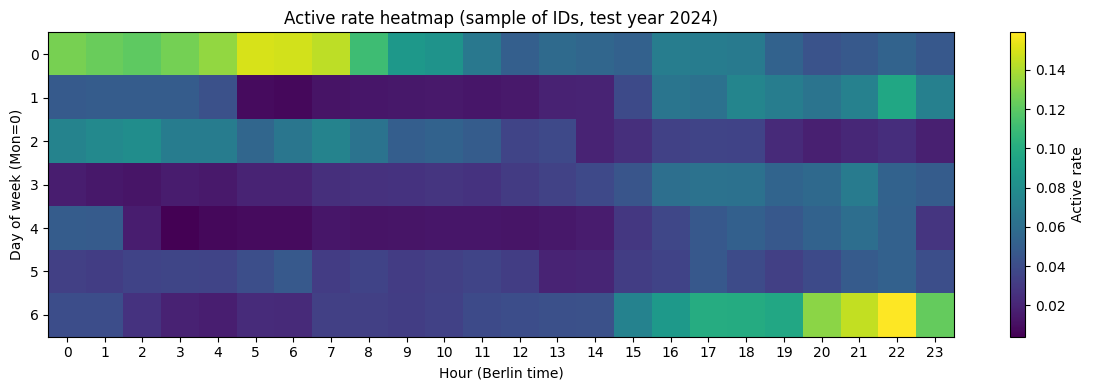

In [ ]:
# === Active heatmap (hour x day) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema
from electricity_forecasting.preprocessing.features import build_15min_grid


HEATMAP_N_IDS = 30
codes = random.sample(ALL_CODES, k=min(HEATMAP_N_IDS, len(ALL_CODES)))
ids_raw = [str(CODE_TO_ID[c]) for c in codes]

df_obs = load_parquet_filtered(
    parquet_path=str(TEST_PARQUET),
    ids=ids_raw,
    columns=[TIME_COL, ID_COL, "high", "low", "close", VOLUME_COL],
    time_min=TEST_START,
    time_max=TEST_END,
)
df_obs = enforce_schema(df_obs)

df_grid = build_15min_grid(
    df_obs=df_obs,
    ids=None,
    start_utc=TEST_START,
    end_utc=TEST_END,
    freq=FREQ,
    id_col=ID_COL,
    time_col=TIME_COL,
    price_cols=PRICE_COLS,
    volume_col=VOLUME_COL,
)

t_local = pd.to_datetime(df_grid[TIME_COL], utc=True).dt.tz_convert("Europe/Berlin")
df_grid["hour"] = t_local.dt.hour.astype(np.int16)
df_grid["dow"] = t_local.dt.dayofweek.astype(np.int16)
df_grid["active"] = (df_grid[VOLUME_COL].to_numpy(np.float32) > 0).astype(np.float32)

pivot = df_grid.groupby(["dow", "hour"])["active"].mean().unstack("hour").fillna(0.0)

plt.figure(figsize=(12, 4))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Active rate")
plt.xticks(ticks=np.arange(pivot.shape[1]), labels=pivot.columns.tolist(), rotation=0)
plt.yticks(ticks=np.arange(pivot.shape[0]), labels=pivot.index.tolist())
plt.xlabel("Hour (Berlin time)")
plt.ylabel("Day of week (Mon=0)")
plt.title("Active rate heatmap (sample of IDs, test year 2024)")
plt.tight_layout()

out_png = PLOTS_DIR / "eda" / "active_rate_heatmap.png"
plt.savefig(out_png, dpi=160)
print("Saved:", out_png.name)

Saved: close_vs_diff_stationarity.png
ADF p-value (Close): 0.01856232464185866
ADF p-value (Diff) : 6.720124797558777e-20


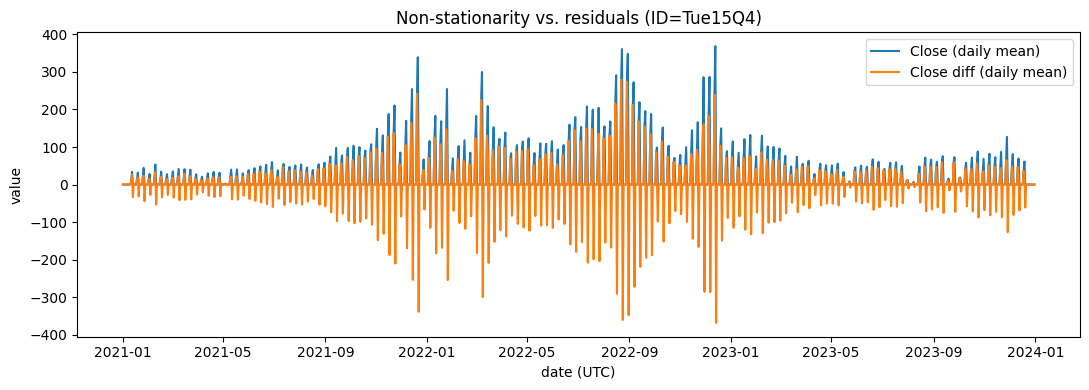

In [ ]:
# === Close vs residual stationarity ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema
from electricity_forecasting.preprocessing.features import build_15min_grid


raw_id = str(sample_raw_ids[0])

df_obs = load_parquet_filtered(
    parquet_path=str(TRAIN_PARQUET),
    ids=[raw_id],
    columns=[TIME_COL, ID_COL, "high", "low", "close", VOLUME_COL],
    time_min=TRAIN_START,
    time_max=TRAIN_END,
)
df_obs = enforce_schema(df_obs)

df_grid = build_15min_grid(
    df_obs=df_obs,
    ids=None,
    start_utc=TRAIN_START,
    end_utc=TRAIN_END,
    freq=FREQ,
)

df_one = df_grid[df_grid[ID_COL].astype(str) == raw_id].copy()
ts = pd.to_datetime(df_one[TIME_COL], utc=True)
close = df_one["close"].astype("float32").to_numpy()

# Daily mean to make the trend visible
s_close = pd.Series(close, index=ts).resample("D").mean().ffill()
s_diff = s_close.diff().fillna(0.0)

plt.figure(figsize=(11, 4))
plt.plot(s_close.index, s_close.values, label="Close (daily mean)")
plt.plot(s_diff.index, s_diff.values, label="Close diff (daily mean)")
plt.title(f"Non-stationarity vs. residuals (ID={raw_id})")
plt.xlabel("date (UTC)")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

out_png = PLOTS_DIR / "eda" / "close_vs_diff_stationarity.png"
plt.savefig(out_png, dpi=160)
print("Saved:", out_png.name)

# Optional: ADF test (if statsmodels is available)
try:
    from statsmodels.tsa.stattools import adfuller

    adf_close = adfuller(s_close.values, autolag="AIC")
    adf_diff = adfuller(s_diff.values, autolag="AIC")

    print("ADF p-value (Close):", float(adf_close[1]))
    print("ADF p-value (Diff) :", float(adf_diff[1]))
except Exception as e:
    print("WARN: ADF test skipped:", repr(e))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Saved: acf_close_30d.png


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


Saved: pacf_close_30d.png


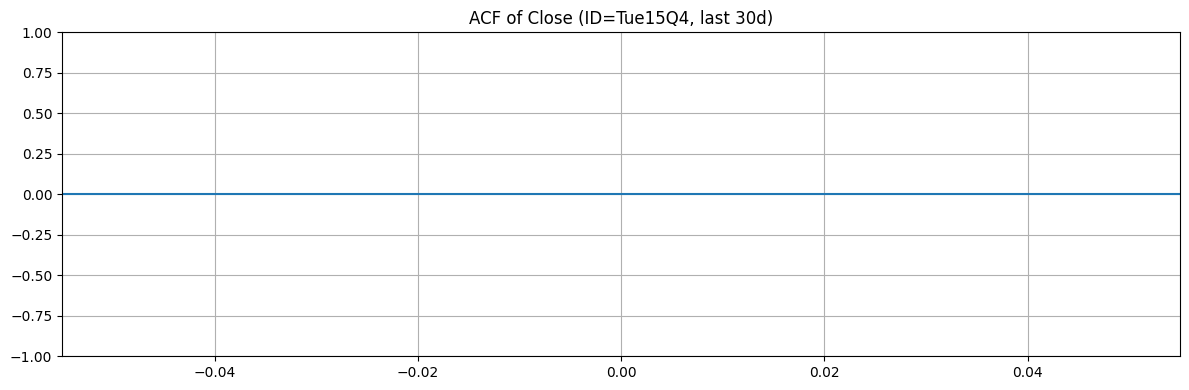

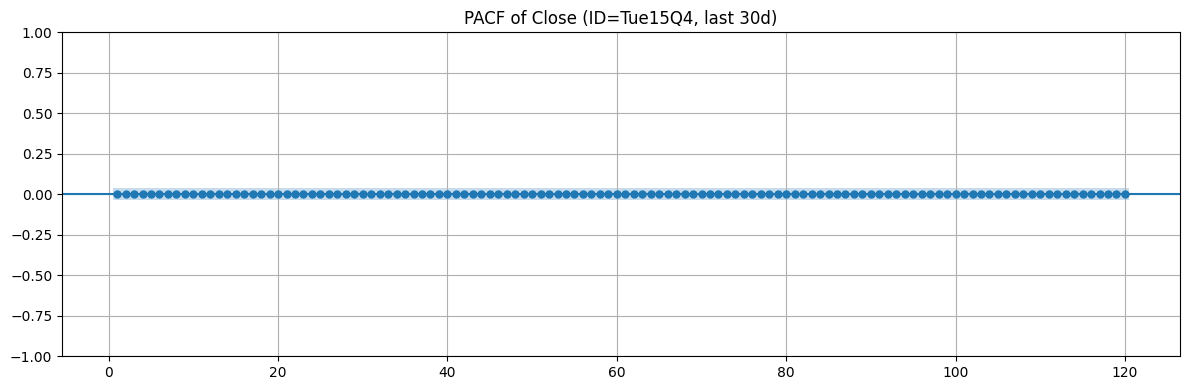

In [ ]:
# === Close ACF/PACF (last 30 days) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema
from electricity_forecasting.preprocessing.features import build_15min_grid

raw_id = str(sample_raw_ids[0])

df_obs = load_parquet_filtered(
    parquet_path=str(TEST_PARQUET),
    ids=[raw_id],
    columns=[TIME_COL, ID_COL, "high", "low", "close", VOLUME_COL],
    time_min=TEST_START,
    time_max=TEST_END,
)
df_obs = enforce_schema(df_obs)

df_grid = build_15min_grid(
    df_obs=df_obs,
    ids=None,
    start_utc=TEST_START,
    end_utc=TEST_END,
    freq=FREQ,
)

df_one = df_grid[df_grid[ID_COL].astype(str) == raw_id].copy()
ts = pd.to_datetime(df_one[TIME_COL], utc=True)
close = pd.Series(df_one["close"].astype("float32").to_numpy(), index=ts).ffill()

# Last 30 days at 15-min resolution
n = 96 * 30
close_30d = close.iloc[-n:].dropna()

try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

    fig, ax = plt.subplots(figsize=(12, 4))
    plot_acf(close_30d.values, lags=120, ax=ax, zero=False)
    ax.set_title(f"ACF of Close (ID={raw_id}, last 30d)")
    ax.grid(True)
    plt.tight_layout()
    out_png = PLOTS_DIR / "eda" / "acf_close_30d.png"
    plt.savefig(out_png, dpi=160)
    print("Saved:", out_png.name)

    fig, ax = plt.subplots(figsize=(12, 4))
    plot_pacf(close_30d.values, lags=120, ax=ax, zero=False, method="ywm")
    ax.set_title(f"PACF of Close (ID={raw_id}, last 30d)")
    ax.grid(True)
    plt.tight_layout()
    out_png = PLOTS_DIR / "eda" / "pacf_close_30d.png"
    plt.savefig(out_png, dpi=160)
    print("Saved:", out_png.name)

except Exception as e:
    print("WARN: statsmodels plots skipped:", repr(e))
    print("Install if needed: pip install statsmodels")


Creating 15-min resampled EDA dataframe for Autocorrelation...
Selected ID for PACF: Wed21Q1
Samples: 4500 | Std(diff(close)): 14.542685508728027


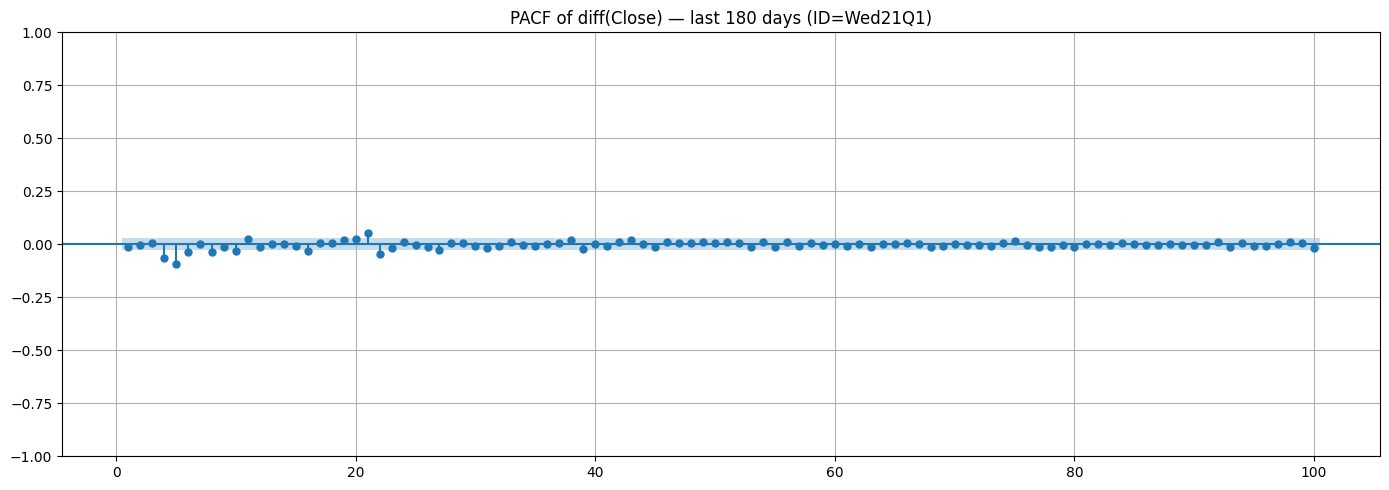

In [ ]:
# === Autocorrelation prep ===

print("\nCreating 15-min resampled EDA dataframe for Autocorrelation...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from statsmodels.graphics.tsaplots import plot_pacf

from electricity_forecasting.io.parquet_io import load_parquet_filtered
from electricity_forecasting.io.schema import enforce_schema

ID_COL = "ID"
TIME_COL = "ExecutionTime"
CLOSE_COL = "close"

DAYS = 180  # was 30
START = TEST_END - pd.Timedelta(days=DAYS)

def load_close_window(raw_id: str) -> pd.Series:
    df_obs = load_parquet_filtered(
        parquet_path=str(TEST_PARQUET),
        ids=[str(raw_id)],
        columns=[TIME_COL, ID_COL, CLOSE_COL],
        time_min=START,
        time_max=TEST_END,
    )
    if df_obs is None or len(df_obs) == 0:
        return pd.Series(dtype="float32")
    df_obs = enforce_schema(df_obs)
    if len(df_obs) == 0:
        return pd.Series(dtype="float32")

    ts = pd.to_datetime(df_obs[TIME_COL], utc=True)
    s = pd.Series(df_obs[CLOSE_COL].astype("float32").to_numpy(), index=ts).sort_index()
    s15 = s.resample("15min").mean().ffill()
    return s15.dropna()

def pick_id_for_pacf(max_tries: int = 120, min_n: int = 2000) -> str:
    codes = random.sample(ALL_CODES, k=min(max_tries, len(ALL_CODES)))
    best_id, best_sd = None, -1.0

    for c in codes:
        rid = str(CODE_TO_ID[c])
        s = load_close_window(rid)
        if s.size < min_n:
            continue
        d = s.diff().dropna()
        if d.size < min_n - 1:
            continue
        sd = float(np.nanstd(d.values))
        if sd > best_sd:
            best_sd, best_id = sd, rid

    if best_id is None or best_sd <= 0:
        raise RuntimeError(f"No informative ID found in last {DAYS} days.")
    return best_id

raw_id = pick_id_for_pacf()
print("Selected ID for PACF:", raw_id)

s = load_close_window(raw_id)
d = s.diff().dropna()

print("Samples:", int(d.size), "| Std(diff(close)):", float(np.nanstd(d.values)))

fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(d.values, lags=100, ax=ax, zero=False, method="ywm",
          title=f"PACF of diff(Close) — last {DAYS} days (ID={raw_id})")
ax.grid(True)
plt.tight_layout()
plt.show()

## 6) How this EDA connects to modeling (03–05)

- The **15‑minute continuous grid** enables deterministic windowing and prevents NaNs.
- **Zero-inflated volume** motivates a **two-head hurdle** model:
  - head1: active probability
  - head2: conditional volume regression (on active only)
- **Periodicity** motivates time features (Berlin hour/dow/month + optional cyclic encoding).
- Evaluation is split into:
  - **Full sMAPE** (includes zeros)
  - **Active sMAPE** (volume > 0 mask)